# K-Means Algorithm

## Initialize K random centroids from the dataset.
## Assign each data point to its nearest centroid.
## Update each centroid by taking the mean of all points assigned to it.
## Repeat Steps 2 and 3 until:
##  ->    the centroids no longer change (convergence), or
##  ->    the maximum number of iterations is reached.

In [3]:
import torch
torch.manual_seed(42)

# Create Dataset

In [4]:
n_samples = 100

cluster1 = torch.randn(n_samples, 2) + torch.tensor([-5.0, -5.0])
cluster2 = torch.randn(n_samples, 2) + torch.tensor([0.0, 5.0])
cluster3 = torch.randn(n_samples, 2) + torch.tensor([5.0, -5.0])

X = torch.cat((cluster1, cluster2, cluster3), dim=0)

print(X.shape)

torch.Size([300, 2])


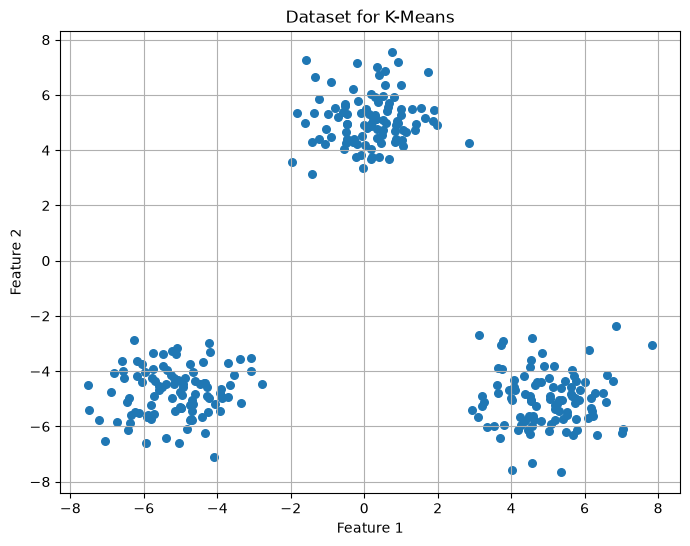

In [7]:
import matplotlib.pyplot as plt

# Plot all data points
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30)

plt.title("Dataset for K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

# Euclidean Distance

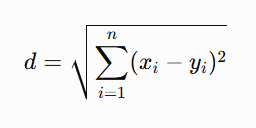

In [10]:
# class EuclideanDistance:
#     def __call__(self,p1,p2):
#         diff = p1 - p2
#         diff = diff**2
#         return torch.sqrt(diff.sum())

class EuclideanDistance:
    def __call__(self, p1, p2):
        return torch.sqrt(((p1 - p2) ** 2).sum())

In [17]:
class KMeans:
    def __init__(self, n_clusters, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter

        self.distance = EuclideanDistance()

    def select_centroids(self, X):
        indices = torch.randperm(len(X))[:self.n_clusters]    #randperm outputs every element once in random order
        centroids = X[indices]
        return centroids

    def assign_clusters(self, X):
        centroids = self.select_centroids(X)
        clusters = [[] for _ in range(self.n_clusters)]     # Create an empty list for every cluster
        for point in X:                                     # Iterate through every point
            min_distance = torch.inf
            nearest_cluster = None                          # Compare point with every centroid
            for idx, centroid in enumerate(centroids):
                current_distance = self.distance(point, centroid)
                if current_distance < min_distance:
                    min_distance = current_distance
                    nearest_cluster = idx                   # Store the point in the nearest cluster
            clusters[nearest_cluster].append(point)
        return clusters

    def update_centroids(self, clusters):
        new_centroids = []

        for cluster in clusters:
            cluster = torch.stack(cluster)
            centroid = cluster.mean(dim=0)
            new_centroids.append(centroid)

        return torch.stack(new_centroids)


    def fit(self, X):
        self.centroids = self.select_centroids(X)               # Step 1: Initialize centroids
        for _ in range(self.max_iter):                          # Step 2: Repeat until convergence
            clusters = self.assign_clusters(X)                  # Assign points using current centroids
            new_centroids = self.update_centroids(clusters)     # Compute new centroids
            if torch.equal(self.centroids, new_centroids):      # Stop if centroids haven't changed
                break
            self.centroids = new_centroids                      # Update centroids


    def predict(self, X):
        predictions = []
        for point in X:
            min_distance = torch.inf
            nearest_cluster = None
            for idx, centroid in enumerate(self.centroids):
                current_distance = self.distance(point, centroid)
                if current_distance < min_distance:
                    min_distance = current_distance
                    nearest_cluster = idx
            predictions.append(nearest_cluster)
        return torch.tensor(predictions)

# Training

In [19]:
model = KMeans(n_clusters=3)

model.fit(X)

print(model.centroids)

tensor([[ 1.5857, -5.1326],
        [-0.1952,  6.1819],
        [-1.9947,  1.2040]])


In [20]:
new_points = torch.tensor([
    [4.8, -5.2],
    [-4.5, -5.4],
    [0.2, 5.8]
])

predictions = model.predict(new_points)

print(predictions)

tensor([0, 0, 1])
